In [1]:
import pandas as pd
import numpy as np
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import PowerTransformer

from funciones import *

In [2]:
# Abrir archivo raw_data
data_folder = "../data"
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha               380 non-null    datetime64[ns]
 1   Close               380 non-null    float64       
 2   Ticker              380 non-null    str           
 3   Beta                314 non-null    float64       
 4   MarketCap           380 non-null    float64       
 5   EnterpriseValue     380 non-null    float64       
 6   PE_Trailing         380 non-null    float64       
 7   EnterpriseToEbitda  380 non-null    float64       
 8   PriceToBook         380 non-null    float64       
 9   operatingMargins    380 non-null    float64       
 10  profitMargins       380 non-null    float64       
 11  returnOnEquity      380 non-null    float64       
 12  ReturnOnAssets      380 non-null    float64       
 13  debtToEquity        380 non-null    float64       
 14  curre

# Variables continuas

In [3]:
# Formatear market cap en billions
df["MarketCap"] = df["MarketCap"] / 10**9

# Distribucion de variables continuas
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
MarketCap,503.0,142.20,471.88,5.10,21.71,40.89,90.88,4984.92
Beta,497.0,0.94,0.48,-0.12,0.59,0.92,1.22,3.45
DividendYield,409.0,2.24,1.59,0.02,1.05,1.85,3.08,11.04
ForwardPE,503.0,12.88,161.60,-3588.03,11.94,16.63,23.26,155.75
trailingPegRatio,435.0,4.11,16.30,0.12,1.09,1.66,2.46,216.92
PriceToBook,503.0,4.78,45.14,-554.93,1.83,3.13,7.47,489.89
EnterpriseToEbitda,472.0,30.94,178.05,-61.62,10.97,14.79,20.93,3023.74
ReturnOnAssets,499.0,0.07,0.06,-0.13,0.03,0.06,0.09,0.53
returnOnEquity,470.0,0.48,4.00,-0.37,0.09,0.16,0.30,84.57
profitMargins,502.0,0.15,0.14,-1.44,0.08,0.13,0.22,0.77


In [4]:
# Coeficientes de asimetria
df.select_dtypes(include="number").skew()

MarketCap               7.845163
Beta                    0.933103
DividendYield           1.224939
ForwardPE             -22.123901
trailingPegRatio        9.908276
PriceToBook            -0.642042
EnterpriseToEbitda     15.189682
ReturnOnAssets          2.592628
returnOnEquity         20.147095
profitMargins          -1.977141
operatingMargins       -0.533289
currentRatio            3.057527
debtToEquity           14.161996
revenueGrowth           5.907449
shortPercentOfFloat     3.185073
dtype: float64

Cont


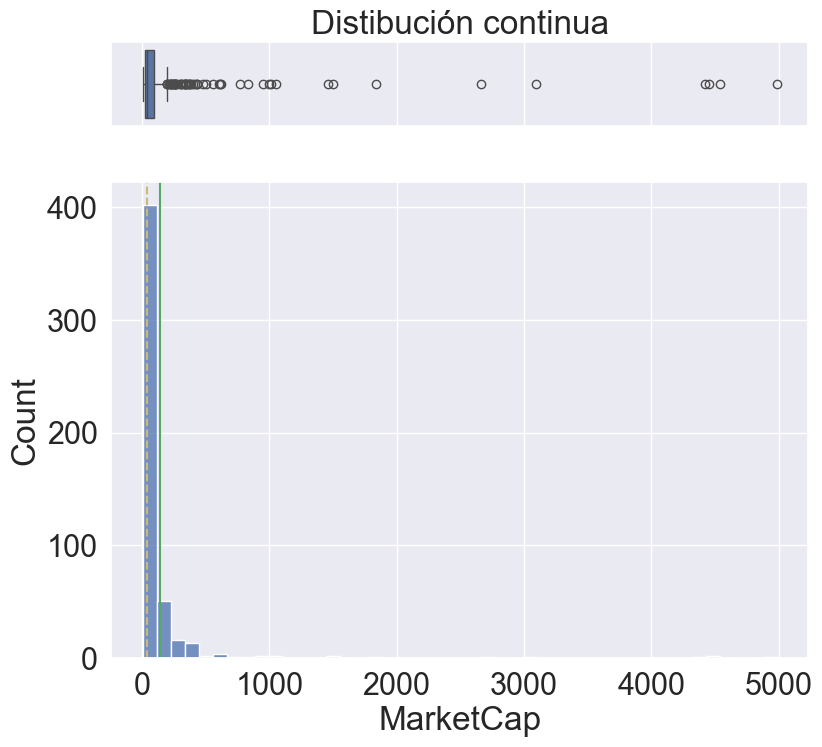

In [5]:
# Graficar
columna_a_graficar = 'MarketCap' # indicar columna para el grafico
plot(df[columna_a_graficar])

Transformaciones yeo-johnson sobre las variables:
* `PriceToBook`
* `returnOnEquity`
* `ForwardPE`

In [6]:
# Transformar
pt = PowerTransformer(method='yeo-johnson', standardize=True)
columnas_a_transformar = ['PriceToBook', 'returnOnEquity', 'ForwardPE']
for columna in columnas_a_transformar:
    df[f'{columna}_Transformed'] = pt.fit_transform(df[[columna]])
    # Elimino la columna sin transformar
    df.drop(columna, axis=1, inplace=True)

Transformaciones logaritmicas sobre las variables:
* `MarketCap`
* `debtToEquity`
* `trailingPegRatio`

In [7]:
# Transformar
columnas_a_transformar = ['MarketCap', 'debtToEquity', 'trailingPegRatio']
for columna in columnas_a_transformar:
    df[f'{columna}_log'] = np.log1p(df[columna])
    df.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df.select_dtypes(include="number").skew()

Beta                           0.933103
DividendYield                  1.224939
EnterpriseToEbitda            15.189682
ReturnOnAssets                 2.592628
profitMargins                 -1.977141
operatingMargins              -0.533289
currentRatio                   3.057527
revenueGrowth                  5.907449
shortPercentOfFloat            3.185073
PriceToBook_Transformed        3.637116
returnOnEquity_Transformed    -0.305703
ForwardPE_Transformed          4.013659
MarketCap_log                  1.033982
debtToEquity_log              -0.199536
trailingPegRatio_log           3.063615
dtype: float64

## Gestion de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [8]:
# Outliers
df_cont = df.select_dtypes(include="number")
df_winsor = df_cont.apply(lambda x: gestiona_outliers(x, clas='winsor'))

Beta
DividendYield
EnterpriseToEbitda
ReturnOnAssets
profitMargins
operatingMargins
currentRatio
revenueGrowth
shortPercentOfFloat
PriceToBook_Transformed
returnOnEquity_Transformed
ForwardPE_Transformed
MarketCap_log
debtToEquity_log
trailingPegRatio_log


In [9]:
# Coeficientes de asimetria actualizados luego de winsorizar
df_winsor.skew()

Beta                          0.899873
DividendYield                 1.224939
EnterpriseToEbitda            0.714855
ReturnOnAssets                1.578870
profitMargins                 0.641756
operatingMargins             -0.533289
currentRatio                  1.637107
revenueGrowth                 1.316628
shortPercentOfFloat           1.588762
PriceToBook_Transformed       0.314745
returnOnEquity_Transformed    0.087640
ForwardPE_Transformed        -1.971304
MarketCap_log                 1.033982
debtToEquity_log             -0.199536
trailingPegRatio_log          1.575513
dtype: float64

Cont


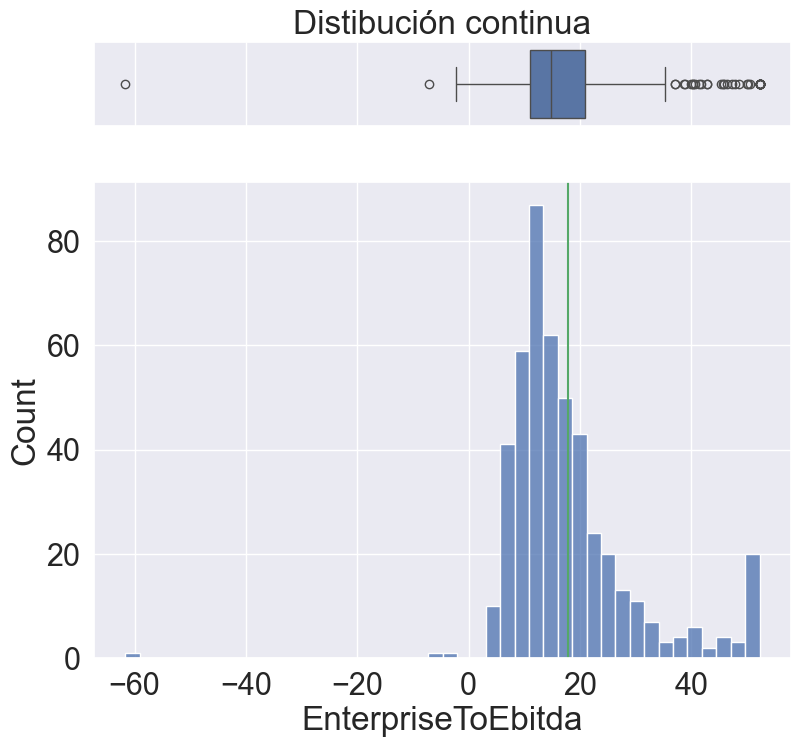

In [10]:
# Visualizar cambios
columna_a_graficar = 'EnterpriseToEbitda' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [11]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
Beta,497.0,0.940296,0.478812,-0.121000,0.588000,0.925000,1.216000,3.320000
DividendYield,409.0,2.240079,1.587946,0.015300,1.050000,1.850000,3.080000,11.040000
EnterpriseToEbitda,472.0,17.852661,11.599557,-61.625000,10.974000,14.793500,20.930000,52.243000
ReturnOnAssets,499.0,0.071406,0.058460,-0.130930,0.031980,0.055990,0.094780,0.324890
profitMargins,502.0,0.151430,0.126600,-0.361410,0.075388,0.131100,0.215875,0.642900
operatingMargins,502.0,0.215283,0.166918,-1.311050,0.110595,0.191315,0.296660,1.074910
currentRatio,482.0,1.496817,0.976846,0.076000,0.896000,1.197000,1.847250,4.782000
revenueGrowth,502.0,0.117331,0.131094,-0.308000,0.043250,0.087500,0.158000,0.520000
shortPercentOfFloat,500.0,0.046065,0.037611,0.000000,0.022275,0.033700,0.057025,0.165300
PriceToBook_Transformed,503.0,-0.015408,0.189420,-0.504490,-0.093244,-0.063910,0.036217,0.438464


In [12]:
# Transformar post winsorizacion: EnterpriseToEbitda
df_winsor['EnterpriseToEbitda_Transformed'] = pt.fit_transform(df_winsor[['EnterpriseToEbitda']])
df_winsor.drop('EnterpriseToEbitda', axis=1, inplace=True)

# Variables Categoricas

In [13]:
df_non_numeric = df.select_dtypes(exclude='number')

In [14]:
# Valores unicos
df_non_numeric.nunique()

Ticker         503
Sector          11
SubIndustry    127
DateAdded      373
dtype: int64

In [15]:
# Convertir Sector y SubIndustrya category
df_non_numeric['Sector'] = df_non_numeric['Sector'].astype('category')
df_non_numeric['SubIndustry'] = df_non_numeric['SubIndustry'].astype('category')

# Valores unicos en Sector
df_non_numeric['Sector'].value_counts()

Sector
Technology                82
Industrials               73
Financial Services        70
Healthcare                60
Consumer Cyclical         53
Consumer Defensive        36
Real Estate               31
Utilities                 31
Communication Services    24
Energy                    22
Basic Materials           20
Name: count, dtype: int64

In [18]:
# Valores unicos en SubIndustry
df_non_numeric['SubIndustry'].value_counts()

SubIndustry
Other                                           29
Health Care Equipment                           17
Electric Utilities                              15
Application Software                            14
Industrial Machinery & Supplies & Components    14
                                                ..
Research & Consulting Services                   2
Self-Storage REITs                               2
Steel                                            2
Tobacco                                          2
Trading Companies & Distributors                 2
Name: count, Length: 99, dtype: int64

In [17]:
# Se agrupan las categorías de SubIndustry con valor único por la categoría "Other"
df_non_numeric['SubIndustry'] = reducir_cardinalidad(df_non_numeric, 'SubIndustry')

In [19]:
df_non_numeric[df_non_numeric['Sector'].isnull()]

,Ticker,Sector,SubIndustry,DateAdded
200,FISV,NaN,Transaction & Payment Processing Services,2001-04-02


In [20]:
# Asignar manualmente el sector a los tickers con valor nulo
df_non_numeric.loc[df_non_numeric['Ticker'] == 'FISV', 'Sector'] = 'Technology'

In [21]:
# Transformar DateAdded a datetime y convertir a YearsSinceAdded
df_non_numeric['DateAdded'] = pd.to_datetime(df_non_numeric['DateAdded'], errors='coerce')
df_non_numeric['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_non_numeric['DateAdded']).dt.days / 365.25), 0)
df_non_numeric.drop('DateAdded', axis=1, inplace=True)

In [22]:
# Merge de variables continuas transformadas y variables no numericas
df_combined = pd.concat([df_non_numeric, df_winsor], axis=1)
df_combined.head()

,Ticker,Sector,SubIndustry,YearsSinceAdded,Beta,DividendYield,ReturnOnAssets,profitMargins,operatingMargins,currentRatio,revenueGrowth,shortPercentOfFloat,PriceToBook_Transformed,returnOnEquity_Transformed,ForwardPE_Transformed,MarketCap_log,debtToEquity_log,trailingPegRatio_log,EnterpriseToEbitda_Transformed
0,MMM,Industrials,Industrial Conglomerates,69.0,1.095,2.04,0.08118,0.11137,0.23317,1.594,0.013,0.0164,0.438464,1.588771,-0.240306,4.390489,5.985187,0.958162,-0.342829
1,AOS,Industrials,Building Products,9.0,1.175,2.49,0.12775,0.13841,0.17111,1.558,-0.019,0.0788,-0.039034,0.436650,-0.348215,2.188718,3.582991,0.905836,-0.643874
2,ABT,Healthcare,Health Care Equipment,69.0,0.620,2.78,0.05590,0.13905,0.13472,1.388,0.078,0.0149,-0.065745,-0.333864,-0.291234,5.073821,4.186209,0.829207,-0.182583
3,ABBV,Healthcare,Biotechnology,13.0,0.309,3.08,0.10032,0.05786,0.32156,0.796,0.124,0.0142,-0.504490,NaN,-0.337046,5.998845,NaN,0.482426,-0.216628
4,ACN,Technology,IT Consulting & Other Services,15.0,1.069,3.65,0.11163,0.10606,0.13819,1.336,0.083,0.0439,-0.055341,0.290944,-0.425322,4.705473,3.275974,0.836988,-0.797166


# Missings

In [23]:
df_combined.isnull().sum()

Ticker                             0
Sector                             0
SubIndustry                        0
YearsSinceAdded                    0
Beta                               6
DividendYield                     94
ReturnOnAssets                     4
profitMargins                      1
operatingMargins                   1
currentRatio                      21
revenueGrowth                      1
shortPercentOfFloat                3
PriceToBook_Transformed            0
returnOnEquity_Transformed        33
ForwardPE_Transformed              0
MarketCap_log                      0
debtToEquity_log                  51
trailingPegRatio_log              68
EnterpriseToEbitda_Transformed    31
dtype: int64

In [24]:
# DividendYield: imputar 0
df_combined['DividendYield'] = df_combined['DividendYield'].fillna(0)

In [25]:
# Resto de las continuas: imputar multivariable con IterativeImputer
df_cont = df_combined.select_dtypes(include='number')
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

In [26]:
df_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   YearsSinceAdded                 503 non-null    float64
 1   Beta                            503 non-null    float64
 2   DividendYield                   503 non-null    float64
 3   ReturnOnAssets                  503 non-null    float64
 4   profitMargins                   503 non-null    float64
 5   operatingMargins                503 non-null    float64
 6   currentRatio                    503 non-null    float64
 7   revenueGrowth                   503 non-null    float64
 8   shortPercentOfFloat             503 non-null    float64
 9   PriceToBook_Transformed         503 non-null    float64
 10  returnOnEquity_Transformed      503 non-null    float64
 11  ForwardPE_Transformed           503 non-null    float64
 12  MarketCap_log                   503 non-null   

In [27]:
df_final = pd.concat([df_imputed, df_combined.select_dtypes(exclude='number')], axis=1)
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   YearsSinceAdded                 503 non-null    float64 
 1   Beta                            503 non-null    float64 
 2   DividendYield                   503 non-null    float64 
 3   ReturnOnAssets                  503 non-null    float64 
 4   profitMargins                   503 non-null    float64 
 5   operatingMargins                503 non-null    float64 
 6   currentRatio                    503 non-null    float64 
 7   revenueGrowth                   503 non-null    float64 
 8   shortPercentOfFloat             503 non-null    float64 
 9   PriceToBook_Transformed         503 non-null    float64 
 10  returnOnEquity_Transformed      503 non-null    float64 
 11  ForwardPE_Transformed           503 non-null    float64 
 12  MarketCap_log                   5

In [28]:
df_final.select_dtypes(include='number').skew()

YearsSinceAdded                   1.028247
Beta                              0.890329
DividendYield                     1.163522
ReturnOnAssets                    1.585611
profitMargins                     0.643643
operatingMargins                 -0.532268
currentRatio                      1.670199
revenueGrowth                     1.318365
shortPercentOfFloat               1.570194
PriceToBook_Transformed           0.314745
returnOnEquity_Transformed        0.124848
ForwardPE_Transformed            -1.971304
MarketCap_log                     1.033982
debtToEquity_log                 -0.128761
trailingPegRatio_log              1.640183
EnterpriseToEbitda_Transformed    0.937258
dtype: float64

In [29]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")